<a href="https://colab.research.google.com/github/Ramjee-Singh/ai_foundation/blob/main/slm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import re
import pandas as pd

### Create tokenizer class which should be able to handle following


1. **Tokenize** - Should be able to tokenize the texts
2. **Vocabulary** - Should create and store vocabulary from text corpus
3. **Token-id mapping**- Should be avble to conver token to id and vice versa to    use in AI/ML models.




In [3]:
from typing import Self
import re

class SimpleWordTokenizer:

  # Define constants.
  UNKNOWN_TOKEN = "<UNK>"
  PAD_TOKEN = "<PAD>"

  def __init__(self, text: str, vocab: list = None): # Added self, changed vocab type hint, added default None
    if vocab: # Correctly checks if vocab is not None and not empty
      self.vocab_list = vocab
    else:
      self.vocab_list = self.build_vocab(text)

    self.token_to_index = {}
    self.index_to_token = {}
    self.vocab_list = self.vocab_list + [self.UNKNOWN_TOKEN, self.PAD_TOKEN] # Corrected order of tokens
    print(f"Built vocabulary: {self.vocab_list}") # Improved print statement

    for index, token in enumerate(self.vocab_list): # Corrected order for enumerate
      self.token_to_index[token] = index
      self.index_to_token[index] = token

  def build_vocab(self, text: str) -> list[str]: # Added self, added return type hint
    tokens = self.space_tokenizer(text)
    vocab_list = sorted(list(set((tokens))))
    return vocab_list

  def space_tokenizer(self, text: str) -> list[str]: # Added self, added return type hint
    tokens = re.split(" +", text)
    return tokens

  def encode(self, tokens: list[str]) -> list[int]: # Added self
    token_ids = []
    for token in tokens:
      if token in self.token_to_index:
        token_ids.append(self.token_to_index[token])
      else:
        # Handle unknown tokens, e.g., by skipping or using a special token ID
        print(f"Warning: Token '{token}' not in vocabulary. Skipping.")
    return token_ids

  def decode(self, token_ids: list[int]) -> str: # Added self
    tokens = []
    for idx in token_ids: # Corrected from token_idx to token_ids
      if idx in self.index_to_token:
        tokens.append(self.index_to_token[idx])
      else:
        # Handle unknown indices
        print(f"Warning: Index '{idx}' not found in vocabulary mapping. Using '<unk>'.")
        tokens.append('<unk>')
    return " ".join(tokens) # Corrected from " ".join[tokens] to " ".join(tokens)


text = "Hello sir how are you Hello hope you are doing fine"
test_word_tokenizer = SimpleWordTokenizer(text)

# Example usage to verify
encoded_tokens = test_word_tokenizer.encode(test_word_tokenizer.space_tokenizer(text))
print(f"Encoded tokens: {encoded_tokens}")
decoded_text = test_word_tokenizer.decode(encoded_tokens)
print(f"Decoded text: {decoded_text}")


Built vocabulary: ['Hello', 'are', 'doing', 'fine', 'hope', 'how', 'sir', 'you', '<UNK>', '<PAD>']
Encoded tokens: [0, 6, 5, 1, 7, 0, 4, 7, 1, 2, 3]
Decoded text: Hello sir how are you Hello hope you are doing fine


### Process Dataset

1. Download dataset [africa_galore](https://storage.googleapis.com/dm-educational/assets/ai_foundations/africa_galore.json)
2. Tokenize and create vocabulary
3. Pad dataset based on avg token length


In [4]:
africa_galore_data = pd.read_json("https://storage.googleapis.com/dm-educational/assets/ai_foundations/africa_galore.json"
)

africa_galore_data['description'][:5]

,description
0,"The Lagos air was thick with humidity, but the..."
1,The warm evening air in Accra was filled with ...
2,The bustling streets of Lagos were alive with ...
3,The Dakar waterfront was buzzing with activity...
4,The Kinshasa night was alive with the infectio...


In [11]:
# Create Tokenizer
text = " ".join(africa_galore_data['description'])
word_tokenizer = SimpleWordTokenizer(text)
len(word_tokenizer.vocab_list)

Built vocabulary: ['"farmer\'s', '"fat', '"grilled', '"medicine"', '"pot', '"stretch', '"vetkoek"', '"virgin")', "'Big", "'Dragon's", "'Etosha'", "'Great", "'Mosi-oa-Tunya'", "'The", "'Timbuktu", "'Tree", "'boss.'", "'dancing'", "'doro", "'ecosystem", "'gomen'", "'king", "'misir", "'mitad,'", "'pap'", "'tear", "'the", "'tuxedo'", "'upside-down", '(1', '(1,200', '(1,840', '(104°F).', '(10ft)', '(122°F)', '(17,057', '(19,341', '(328', '(33ft)', '(350,000', '(45', '(5,657', '(5,800', '(60', '(7,523', '(75°F', '(79', '(Acacia', '(Akan,', '(Arabic,', '(Attaya)', "(B'stilla)", '(Bambara,', '(Eswatini)', '(Ethiopian', '(Hausa),', '(Koshari)', '(Mahewu)', '(May', '(Panthera', '(Poulet', '(Somali,', '(South', '(Spheniscus', '(Swahili,', '(Vachellia', '(Wolof,', '(a', '(also', '(and', '(banku)', '(barbecues).', '(braais)', '(c.', '(called', '(carbohydrates,', '(chicken', '(collard', '(corn),', '(each', '(egusi),', '(extinct,', '(fermented', '(for', '(genus', '(guesthouses),', '(hominy)', '(known

5261

In [14]:
# Check encode and decode
encoded_tokens = word_tokenizer.encode(africa_galore_data['description'][0].split())
print(f"Encoded tokens: {encoded_tokens}")
decoded_text = word_tokenizer.decode(encoded_tokens)
print(f"Decoded text: {decoded_text}")

Encoded tokens: [812, 509, 983, 5090, 4800, 5181, 2798, 1361, 4790, 2132, 2854, 4790, 1582, 5090, 2086, 812, 1132, 3041, 2920, 910, 2819, 168, 2621, 4790, 2021, 3805, 3574, 910, 1651, 3770, 4790, 2773, 1242, 910, 4407, 3278, 1028, 4790, 1156, 3047, 1990, 910, 1866, 2484, 2435, 133, 5187, 3420, 443, 3386, 2076, 4847, 4790, 3405, 2704, 1257, 4690, 2854, 4837, 5181, 4790, 4076, 812, 3404, 4257, 4847, 2387, 4829, 2705, 910, 3819, 1827, 3520, 2132, 1028, 2953, 183, 1074, 2705, 3681, 5141, 1847, 4341, 1028, 1544, 1444, 4981, 2854, 4790, 2874, 4076, 812, 3404, 5090, 3364, 4786, 2966, 2149, 2936, 5090, 910, 1448, 3520, 3099, 910, 1670, 4847, 4791, 4293, 2719, 910, 5034, 2222, 3520, 4790, 4435, 3520, 511]
Decoded text: The Lagos air was thick with humidity, but the energy in the club was electric. The band launched into a hypnotic Afrobeat groove, the drums pounding out a complex polyrhythm, the horns blaring a soaring melody, and the bass laying down a deep, funky foundation. A woman named Ima

#### Apply padding for uniform sequence/context length

In [6]:
# find min and max paragraph length
word_count = africa_galore_data['description'].apply(lambda x: len(x.split()))
min_paragraph_length = word_count.min()
max_paragraph_length = word_count.max()
min_index = africa_galore_data['description'] \
    .apply(lambda x: len(x.split())) \
    .idxmin()
max_index = africa_galore_data['description'] \
    .apply(lambda x: len(x.split())) \
    .idxmax()
print(f"Min paragraph length: {min_paragraph_length}, index {min_index}")
print(f"Max paragraph length: {max_paragraph_length}, index {max_index}")

Min paragraph length: 26, index 174
Max paragraph length: 318, index 22


In [7]:
# Verify min max token counts
#len(africa_galore_data['description'][22].split())
#len(africa_galore_data['description'][174].split())

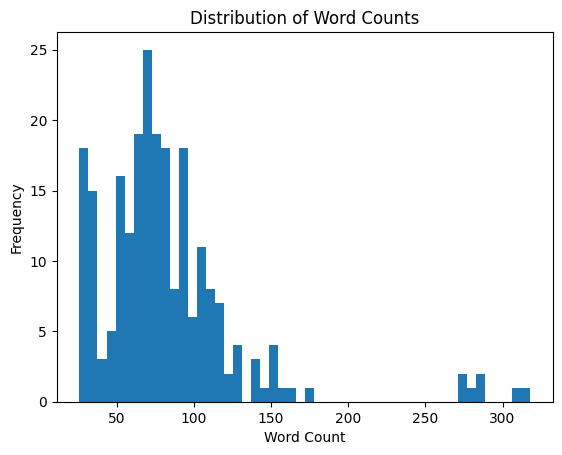

In [15]:
# Plot/Analyse word count for dataset with mean and variance
import matplotlib.pyplot as plt
plt.hist(word_count, bins=50)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Word Counts")
plt.show()

In [ ]:
#Apply max padding
africa_galore_data['tokens'] = africa_galore_data['description'].apply(lambda x: x.split())
context_len = max_paragraph_length
padding_token = "<PAD>"

def pad_sequence(tokens):
    tokens = tokens[:context_len]  # truncate
    return tokens + [padding_token] * (context_len - len(tokens))

africa_galore_data['padded'] = africa_galore_data['tokens'].apply(pad_sequence)





### Prepare model inputs and parameters

In [ ]:
import torch
data = torch.tensor(africa_galore_data['padded'].tolist())
inputs = data[:, :-1]
targets = data[:, 1:]

